- Which are the top 5 companies offering the highest average salary?
- Which are the top 5 companies with salaries reported more than 20 times?
- Is there a measurable relationship between company rating and salary?
- How does employment status (e.g., Full-time vs. Contract) affect salary?
- Which job roles are most common in this dataset?
- How significantly do salaries vary across different geographic locations?


# The salary dataset

### Import required libraries

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use("default")
sns.set_context("notebook", font_scale=1.2)

%matplotlib inline


### Load Dataset

In [2]:
df = pd.read_csv("Salary_Dataset_DSL.csv")
df.head()

,Rating,Company Name,Job Title,Salary,Salaries Reported,Location,Employment Status,Job Roles
0,3.8,Sasken,Android Developer,400000,3,Bangalore,Full Time,Android
1,4.5,Advanced Millennium Technologies,Android Developer,400000,3,Bangalore,Full Time,Android
2,4.0,Unacademy,Android Developer,1000000,3,Bangalore,Full Time,Android
3,3.8,SnapBizz Cloudtech,Android Developer,300000,3,Bangalore,Full Time,Android
4,4.4,Appoids Tech Solutions,Android Developer,600000,3,Bangalore,Full Time,Android


In [4]:
df.shape

(22770, 8)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22770 entries, 0 to 22769
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Rating             22770 non-null  float64
 1   Company Name       22769 non-null  object 
 2   Job Title          22770 non-null  object 
 3   Salary             22770 non-null  int64  
 4   Salaries Reported  22770 non-null  int64  
 5   Location           22770 non-null  object 
 6   Employment Status  22770 non-null  object 
 7   Job Roles          22770 non-null  object 
dtypes: float64(1), int64(2), object(5)
memory usage: 1.4+ MB


In [7]:
df.describe(include="all")

,Rating,Company Name,Job Title,Salary,Salaries Reported,Location,Employment Status,Job Roles
count,22770.000000,22769,22770,2.277000e+04,22770.000000,22770,22770,22770
unique,NaN,11260,1080,NaN,NaN,10,4,11
top,NaN,Tata Consultancy Services,Software Development Engineer,NaN,NaN,Bangalore,Full Time,SDE
freq,NaN,271,2351,NaN,NaN,8264,20083,8183
mean,3.918213,NaN,NaN,6.953872e+05,1.855775,NaN,NaN,NaN
std,0.519675,NaN,NaN,8.843990e+05,6.823668,NaN,NaN,NaN
min,1.000000,NaN,NaN,2.112000e+03,1.000000,NaN,NaN,NaN
25%,3.700000,NaN,NaN,3.000000e+05,1.000000,NaN,NaN,NaN
50%,3.900000,NaN,NaN,5.000000e+05,1.000000,NaN,NaN,NaN
75%,4.200000,NaN,NaN,9.000000e+05,1.000000,NaN,NaN,NaN


### Data Cleaning

In [8]:
df.isna().sum()

Rating               0
Company Name         1
Job Title            0
Salary               0
Salaries Reported    0
Location             0
Employment Status    0
Job Roles            0
dtype: int64

In [9]:
df.dropna(inplace=True)

In [12]:
df = df.drop_duplicates()
df

,Rating,Company Name,Job Title,Salary,Salaries Reported,Location,Employment Status,Job Roles
0,3.8,Sasken,Android Developer,400000,3,Bangalore,Full Time,Android
1,4.5,Advanced Millennium Technologies,Android Developer,400000,3,Bangalore,Full Time,Android
2,4.0,Unacademy,Android Developer,1000000,3,Bangalore,Full Time,Android
3,3.8,SnapBizz Cloudtech,Android Developer,300000,3,Bangalore,Full Time,Android
4,4.4,Appoids Tech Solutions,Android Developer,600000,3,Bangalore,Full Time,Android
...,...,...,...,...,...,...,...,...
22765,4.7,Expert Solutions,Web Developer,200000,1,Bangalore,Full Time,Web
22766,4.0,Nextgen Innovation Labs,Web Developer,300000,1,Bangalore,Full Time,Web
22767,4.1,Fresher,Full Stack Web Developer,192000,13,Bangalore,Full Time,Web
22768,4.1,Accenture,Full Stack Web Developer,300000,7,Bangalore,Full Time,Web


### Outlier Detection & Removal

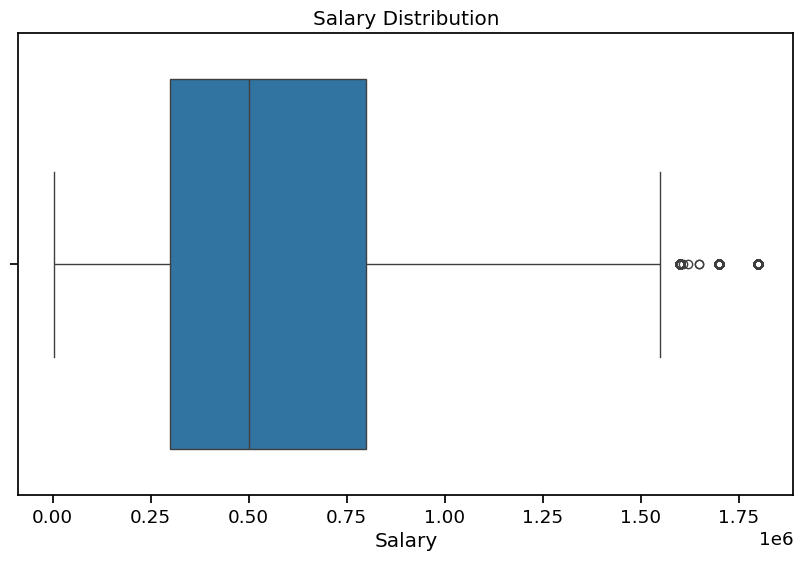

In [30]:
plt.figure(figsize=(10, 6))
sns.boxplot(x="Salary", data=df)
plt.title("Salary Distribution")
plt.show()

In [31]:
# IQR method to detect outliers
Q1 = df["Salary"].quantile(0.25)
Q3 = df["Salary"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df["Salary"] < lower_bound) | (df["Salary"] > upper_bound)]
outliers

,Rating,Company Name,Job Title,Salary,Salaries Reported,Location,Employment Status,Job Roles
267,3.4,News Corp,Android Developer,1600000,1,Bangalore,Full Time,Android
284,4.1,Tesco Bengaluru,Android Developer,1800000,1,Bangalore,Full Time,Android
327,3.6,JustDial,Android Developer,1600000,1,Bangalore,Full Time,Android
401,4.0,Falabella India,Android Developer,1600000,1,Bangalore,Full Time,Android
425,4.4,ShareChat,Android Developer,1700000,1,Bangalore,Full Time,Android
...,...,...,...,...,...,...,...,...
21493,3.3,Tricon,Test Engineer,1600000,1,Bangalore,Full Time,Testing
21519,4.7,FreJun,Test Engineer,1700000,1,Bangalore,Full Time,Testing
21574,4.0,Analog Devices,Test Engineer,1600000,1,Bangalore,Full Time,Testing
22379,3.7,OneDirect (India),Web Developer,1700000,1,Bangalore,Full Time,Web


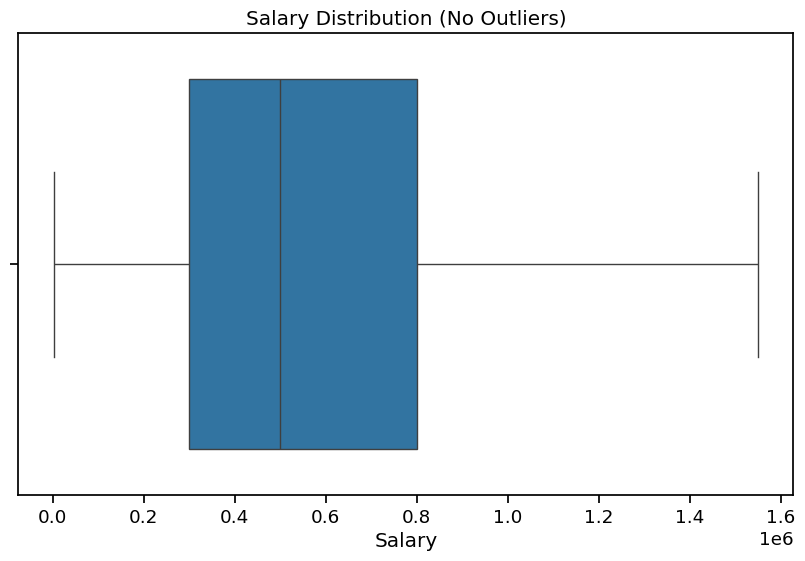

In [32]:
df_no_outliers = df[(df["Salary"] >= lower_bound) & (df["Salary"] <= upper_bound)]
plt.figure(figsize=(10, 6))
sns.boxplot(x="Salary", data=df_no_outliers)
plt.title("Salary Distribution (No Outliers)")
plt.show()

### Univariate Analysis

In [33]:
df = df_no_outliers

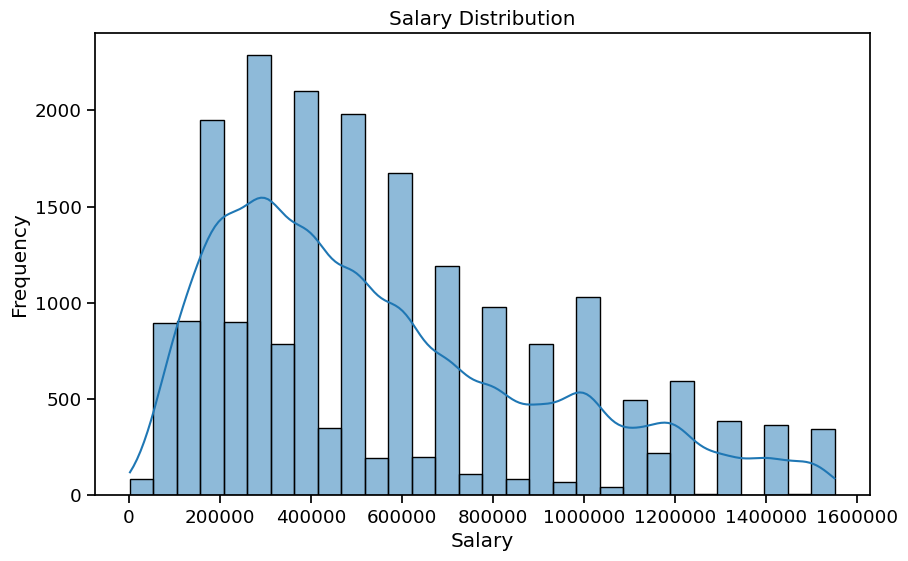

In [81]:
plt.figure(figsize=(10, 6))
sns.histplot(df["Salary"], bins=30, kde=True)
plt.title("Salary Distribution")
plt.xlabel("Salary")
plt.ticklabel_format(style="plain", axis="x")
plt.ylabel("Frequency")
plt.savefig("Figures/salary_distribution.png")
plt.show()

### **Q1. What does the overall salary distribution look like?**


In [35]:
df.columns

Index(['Rating', 'Company Name', 'Job Title', 'Salary', 'Salaries Reported',
       'Location', 'Employment Status', 'Job Roles'],
      dtype='object')

In [36]:
df["Job Roles"].value_counts()

Job Roles
SDE         7244
Android     2812
Frontend    2034
Java        1778
Testing     1710
IOS         1524
Backend     1049
Web          988
Python       929
Database     734
Mobile       211
Name: count, dtype: int64

In [37]:
job_role_top10 = df.groupby("Job Roles")["Salary"].mean().sort_values(ascending=False).head(10)
job_role_top10

Job Roles
Database    702554.768392
SDE         648108.015461
IOS         593214.068241
Mobile      589857.819905
Backend     529104.564347
Frontend    501977.282203
Android     483352.318634
Java        475832.116985
Testing     464824.757895
Python      449531.694295
Name: Salary, dtype: float64

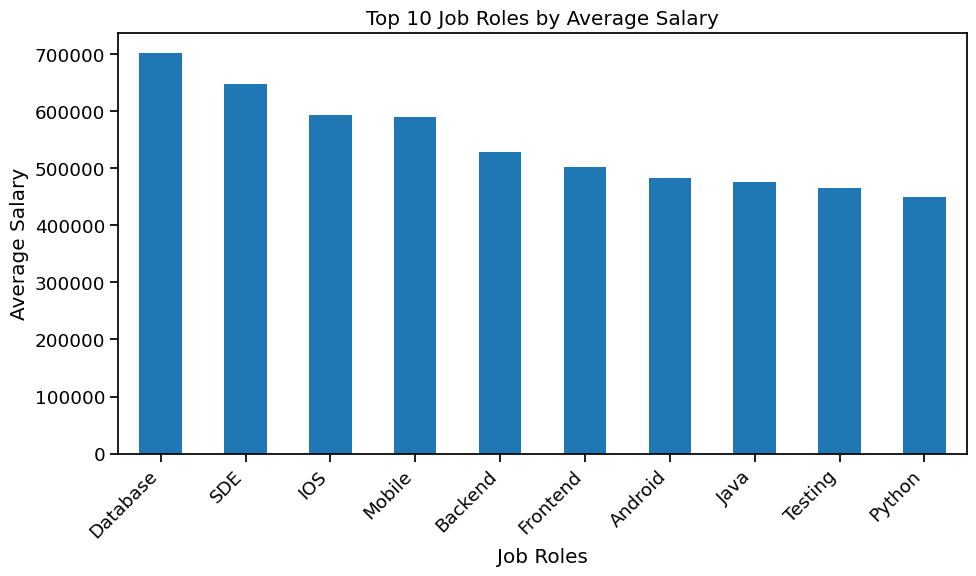

In [82]:
plt.figure(figsize=(10, 6))
job_role_top10.plot(kind="bar")
plt.title("Top 10 Job Roles by Average Salary")
plt.xlabel("Job Roles")
plt.ylabel("Average Salary")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("Figures/top_job_roles.png")
plt.show()

### **Q2. - Which cities offer the highest average salary?**

In [40]:
city_salary = df.groupby("Location")["Salary"].mean().sort_values(ascending=False)
city_salary.head(10)

Location
Mumbai            702195.874214
Bangalore         568140.303079
Jaipur            566153.846154
Pune              562387.138833
New Delhi         542717.057751
Hyderabad         538809.567450
Kolkata           532604.938272
Kerala            514965.735849
Chennai           505102.446337
Madhya Pradesh    497530.378378
Name: Salary, dtype: float64

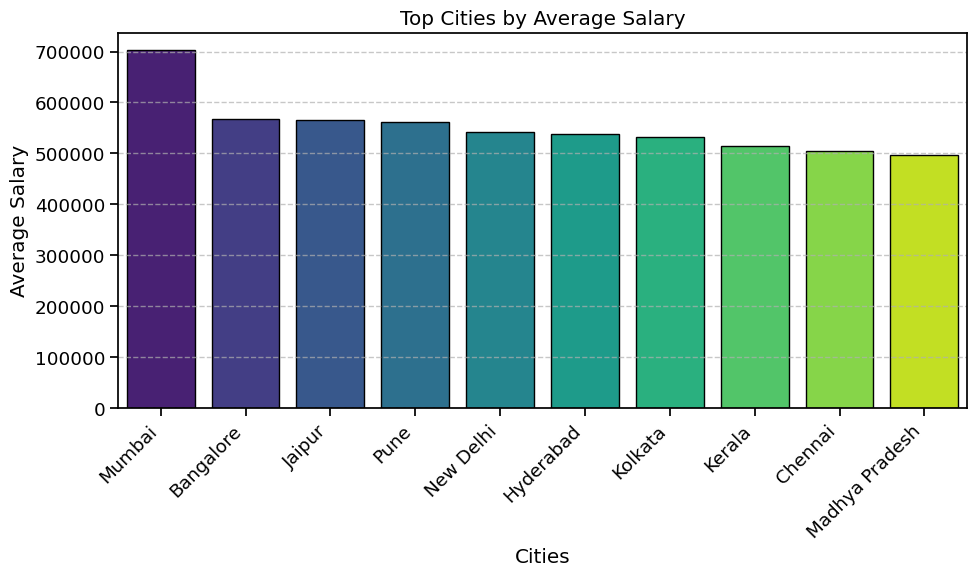

In [83]:
plt.figure(figsize=(10, 6))
city_salary.plot(kind="bar")
colors = sns.color_palette("viridis", len(city_salary))
plt.bar(city_salary.index, city_salary.values, color=colors, edgecolor="black")
plt.title("Top Cities by Average Salary")
plt.xlabel("Cities")
plt.ylabel("Average Salary")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.savefig("Figures/top_cities.png")
plt.show()

### **Q3. Name those 5 companies located in 'New Delhi' with Ratings of '5', offering highest & lowest salaries**

In [47]:
df1 = df[(df["Location"] == "New Delhi") & (df["Rating"] == 5)].sort_values(by="Salary", ascending=False)
df1

,Rating,Company Name,Job Title,Salary,Salaries Reported,Location,Employment Status,Job Roles
1888,5.0,Trillbit,Android Developer,1500000,1,New Delhi,Full Time,Android
6750,5.0,Hapramp,Front End Developer,1500000,1,New Delhi,Full Time,Frontend
17488,5.0,The Art of Mike Mignola,Software Development Engineer,1500000,1,New Delhi,Full Time,SDE
8284,5.0,Silicon Valley Recycling,Senior IOS Developer,1400000,1,New Delhi,Full Time,IOS
17351,5.0,Parth Universal,Software Development Engineer,1300000,1,New Delhi,Full Time,SDE
...,...,...,...,...,...,...,...,...
8008,5.0,Rabbler,IOS Developer Contractor,100000,1,New Delhi,Contractor,IOS
1969,5.0,WorkingNation,Android Developer - Intern,84000,1,New Delhi,Intern,Android
2334,5.0,Hopin (India),Android Developer - Intern,60000,1,New Delhi,Intern,Android
17524,5.0,Star Catalysts,Software Development Engineer - Intern,60000,1,New Delhi,Intern,SDE


In [48]:
df1[["Company Name","Salary"]]

,Company Name,Salary
1888,Trillbit,1500000
6750,Hapramp,1500000
17488,The Art of Mike Mignola,1500000
8284,Silicon Valley Recycling,1400000
17351,Parth Universal,1300000
...,...,...
8008,Rabbler,100000
1969,WorkingNation,84000
2334,Hopin (India),60000
17524,Star Catalysts,60000


### **Q4. Which Job title has the highest number of salary reported?**

In [51]:
df.head()

,Rating,Company Name,Job Title,Salary,Salaries Reported,Location,Employment Status,Job Roles
0,3.8,Sasken,Android Developer,400000,3,Bangalore,Full Time,Android
1,4.5,Advanced Millennium Technologies,Android Developer,400000,3,Bangalore,Full Time,Android
2,4.0,Unacademy,Android Developer,1000000,3,Bangalore,Full Time,Android
3,3.8,SnapBizz Cloudtech,Android Developer,300000,3,Bangalore,Full Time,Android
4,4.4,Appoids Tech Solutions,Android Developer,600000,3,Bangalore,Full Time,Android


In [50]:
df["Job Title"].value_counts()

Job Title
Software Development Engineer               2136
Android Developer                           1983
Software Development Engineer (SDE)         1477
Front End Developer                         1360
Test Engineer                               1290
                                            ... 
Software Testing                               1
Automation Tester                              1
Web Developer/Android Developer - Intern       1
QA Analyst, Automation Test Engineer           1
Senior Test Lead                               1
Name: count, Length: 981, dtype: int64

In [53]:
df.groupby("Job Title")["Salaries Reported"].count().sort_values(ascending=False)

Job Title
Software Development Engineer                        2136
Android Developer                                    1983
Software Development Engineer (SDE)                  1477
Front End Developer                                  1360
Test Engineer                                        1290
                                                     ... 
UI/User Experience Designer & Front End Developer       1
UI/UX Designer & Front End Developer                    1
UI Front End Developer                                  1
Trainee Test Engineer - Contractor                      1
Trainee Engineer – Software Development                 1
Name: Salaries Reported, Length: 981, dtype: int64

### **Q5. Which 10 companies provide the highest average salary, when at least 20 employees have reported their salaries?**

In [58]:
reported_20 = df[(df["Salaries Reported"] >= 20)]
reported_20.groupby("Company Name")["Salary"].mean().sort_values(ascending=False).head(10)

Company Name
Expedia Group     1.350000e+06
Nokia             1.200000e+06
Amadeus           1.200000e+06
Alcatel-Lucent    1.000000e+06
Ola               1.000000e+06
Kony              9.000000e+05
Lumen             9.000000e+05
Microsoft         7.845714e+05
Cisco Systems     7.000000e+05
McAfee            6.500000e+05
Name: Salary, dtype: float64

### **Q5. Check and show the relationship Between Ratings and Salary**

In [59]:
df["Rating"].corr(df["Salary"])

np.float64(0.024759533647245237)

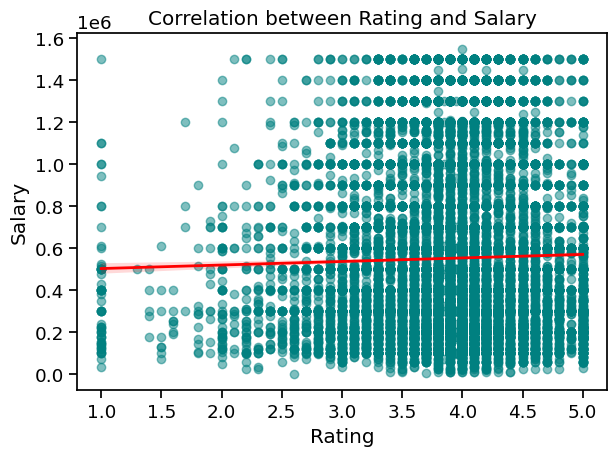

In [64]:
sns.regplot(x="Rating", y="Salary", data=df, scatter_kws={"alpha": 0.5, "color":"teal"}, line_kws={"color":"red", "linewidth":2})
plt.title("Correlation between Rating and Salary")
plt.xlabel("Rating")
plt.ylabel("Salary")
plt.tight_layout()
plt.show()

### **Q6. Does employement status affect salary?**

In [65]:
df.head()

,Rating,Company Name,Job Title,Salary,Salaries Reported,Location,Employment Status,Job Roles
0,3.8,Sasken,Android Developer,400000,3,Bangalore,Full Time,Android
1,4.5,Advanced Millennium Technologies,Android Developer,400000,3,Bangalore,Full Time,Android
2,4.0,Unacademy,Android Developer,1000000,3,Bangalore,Full Time,Android
3,3.8,SnapBizz Cloudtech,Android Developer,300000,3,Bangalore,Full Time,Android
4,4.4,Appoids Tech Solutions,Android Developer,600000,3,Bangalore,Full Time,Android


In [67]:
df["Employment Status"].value_counts()

Employment Status
Full Time     18378
Intern         2089
Contractor      513
Trainee          33
Name: count, dtype: int64

In [70]:
df.groupby("Employment Status")["Salary"].describe()

,count,mean,std,min,25%,50%,75%,max
Employment Status,,,,,,,,
Contractor,513.0,501507.586745,315663.813209,12000.0,300000.0,400000.0,600000.0,1500000.0
Full Time,18378.0,579272.415279,358047.046792,8448.0,300000.0,500000.0,800000.0,1550000.0
Intern,2089.0,338353.991383,264180.887035,2112.0,144000.0,264000.0,456000.0,1500000.0
Trainee,33.0,324303.030303,241096.516572,96000.0,144000.0,240000.0,400000.0,1100000.0


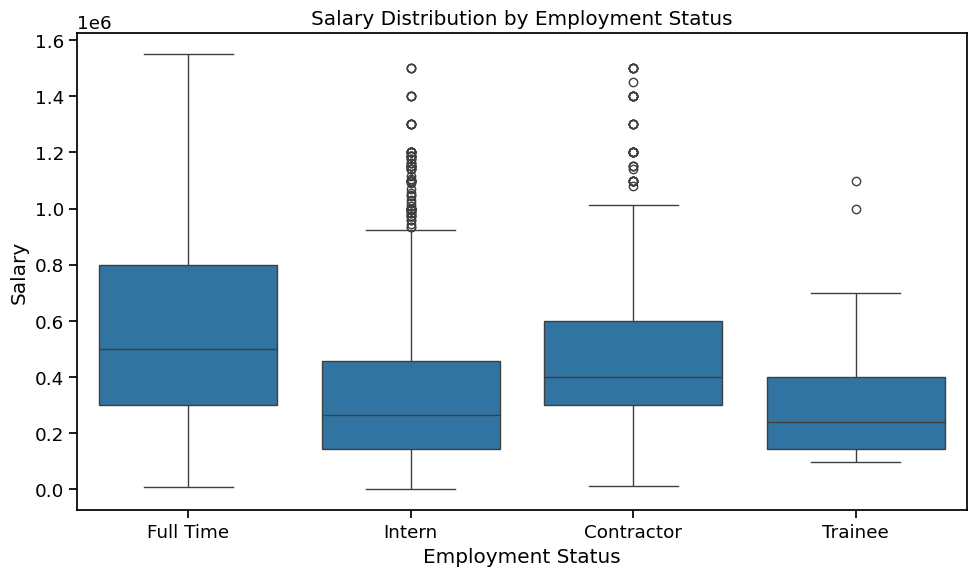

In [84]:
plt.figure(figsize=(10, 6))
sns.boxplot(x="Employment Status", y="Salary", data=df)
plt.title("Salary Distribution by Employment Status")
plt.xlabel("Employment Status")
plt.ylabel("Salary")
plt.tight_layout()
plt.savefig("Figures/salary_by_employment_status.png")
plt.show()

### **Q7. Whichi job roles are most common?**

In [72]:
df

,Rating,Company Name,Job Title,Salary,Salaries Reported,Location,Employment Status,Job Roles
0,3.8,Sasken,Android Developer,400000,3,Bangalore,Full Time,Android
1,4.5,Advanced Millennium Technologies,Android Developer,400000,3,Bangalore,Full Time,Android
2,4.0,Unacademy,Android Developer,1000000,3,Bangalore,Full Time,Android
3,3.8,SnapBizz Cloudtech,Android Developer,300000,3,Bangalore,Full Time,Android
4,4.4,Appoids Tech Solutions,Android Developer,600000,3,Bangalore,Full Time,Android
...,...,...,...,...,...,...,...,...
22765,4.7,Expert Solutions,Web Developer,200000,1,Bangalore,Full Time,Web
22766,4.0,Nextgen Innovation Labs,Web Developer,300000,1,Bangalore,Full Time,Web
22767,4.1,Fresher,Full Stack Web Developer,192000,13,Bangalore,Full Time,Web
22768,4.1,Accenture,Full Stack Web Developer,300000,7,Bangalore,Full Time,Web


In [74]:
top_roles =df["Job Roles"].value_counts().head(10)

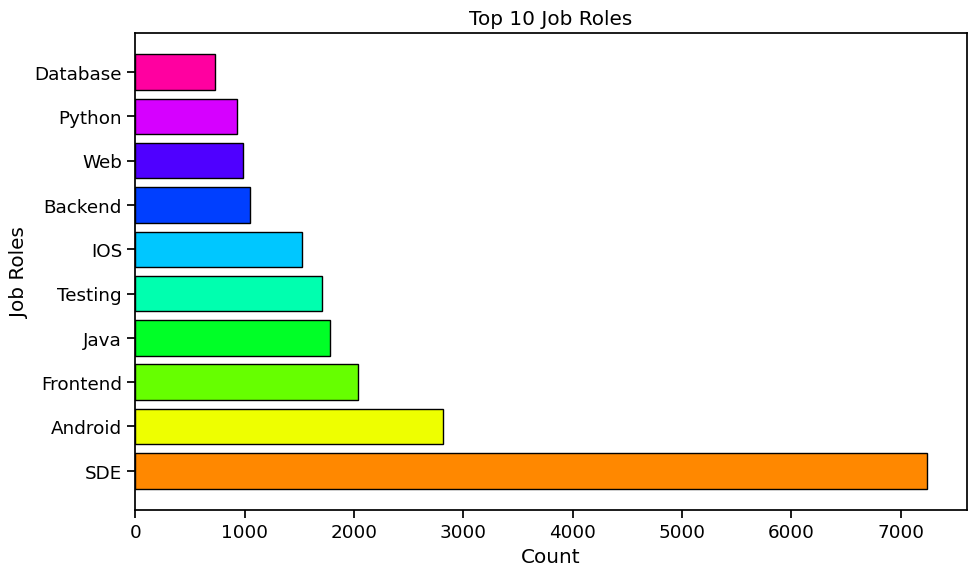

In [85]:
plt.figure(figsize=(10, 6))
colors = sns.color_palette("hsv", len(top_roles))
plt.barh(top_roles.index, top_roles.values, color=colors, edgecolor="black")
plt.title("Top 10 Job Roles")
plt.xlabel("Count")
plt.ylabel("Job Roles")
plt.tight_layout()
plt.savefig("Figures/top_job_roles.png")
plt.show()

### **Q8. How does average salary changes as comapny rating increase**

In [79]:
rating_salary = df.groupby("Rating")["Salary"].mean().sort_values(ascending=False).reset_index()
rating_salary.head()

,Rating,Salary
0,1.70,750000.000000
1,3.85,598909.090909
2,3.40,581967.586716
3,3.80,581869.033943
4,3.90,581744.937858


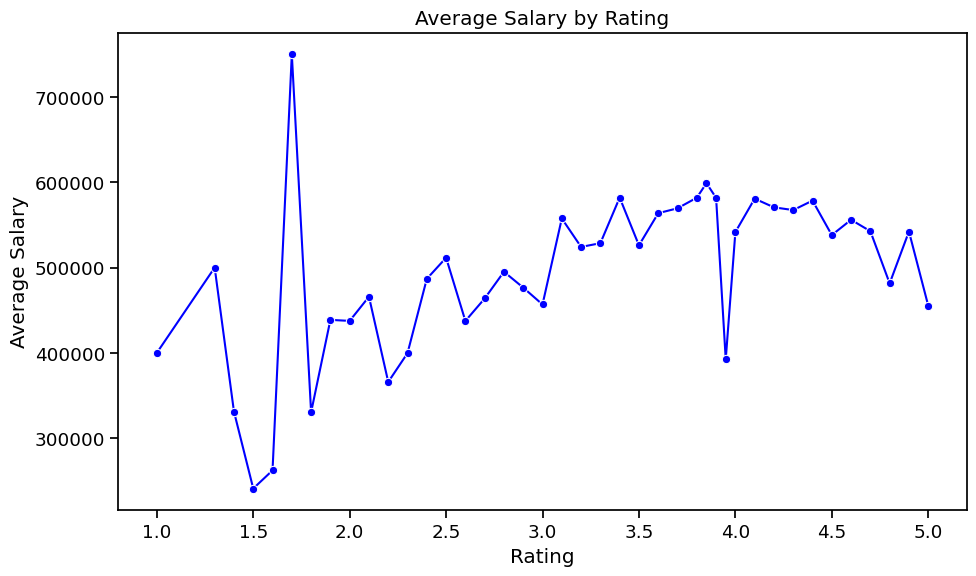

In [86]:
plt.figure(figsize=(10, 6))
sns.lineplot(x="Rating", y="Salary", data=rating_salary, marker="o", color="blue")
plt.title("Average Salary by Rating")
plt.xlabel("Rating")
plt.ylabel("Average Salary")
plt.tight_layout()
plt.savefig("Figures/average_salary_by_rating.png")
plt.show()